
# Producto 2.º Parcial — Análisis predictivo con SVM

## Clasificación predictiva de tumores mamarios

**Objetivo ejecutivo:** construir un modelo supervisado capaz de clasificar registros clínicos como **benignos** o **malignos**, con énfasis en detectar la mayor cantidad posible de casos malignos para apoyar la priorización de revisiones médicas.

**Algoritmo seleccionado:** Máquina de Vectores de Soporte (**SVM**) con kernel RBF. Este algoritmo aparece en los laboratorios revisados y se eligió porque funciona bien con múltiples variables numéricas, relaciones no lineales y datos correctamente escalados.

> **Nota:** este ejercicio es académico. El modelo no sustituye el diagnóstico de profesionales de la salud ni constituye un dispositivo médico.


## 1. Importación de librerías

In [1]:

# Manipulación y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos y modelado
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

# Evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 35)



## 2. Obtención y comprensión de los datos

Se utiliza el conjunto **Breast Cancer Wisconsin Diagnostic**, incluido en `scikit-learn`. Contiene mediciones numéricas calculadas a partir de imágenes digitalizadas de aspirados con aguja fina de masas mamarias.

- **Registros:** 569.
- **Variables predictoras:** 30 mediciones numéricas.
- **Variable objetivo original:** `0 = maligno`, `1 = benigno`.
- Para facilitar la interpretación ejecutiva, se recodifica como `riesgo_maligno`: **1 = maligno** y **0 = benigno**.


In [2]:

# Carga del dataset
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()

# Recodificación: 1 representa el evento de mayor riesgo (maligno)
df['riesgo_maligno'] = (df['target'] == 0).astype(int)
df.drop(columns=['target'], inplace=True)

print(f'Dimensiones: {df.shape[0]} registros y {df.shape[1] - 1} variables predictoras')
print()
print('Distribución de la variable objetivo:')
print(df['riesgo_maligno'].value_counts().rename(index={0: 'Benigno', 1: 'Maligno'}))

df.head()


Dimensiones: 569 registros y 30 variables predictoras

Distribución de la variable objetivo:
riesgo_maligno
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,riesgo_maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Calidad inicial y limpieza

In [3]:

# Revisión de calidad
resumen_calidad = pd.DataFrame({
    'tipo_dato': df.dtypes,
    'nulos': df.isna().sum(),
    'valores_unicos': df.nunique()
})

print(f'Total de valores nulos: {int(df.isna().sum().sum())}')
print(f'Registros duplicados: {int(df.duplicated().sum())}')
print(f'Columnas numéricas: {df.select_dtypes(include=np.number).shape[1]}')
resumen_calidad.head(10)


Total de valores nulos: 0
Registros duplicados: 0
Columnas numéricas: 31


,tipo_dato,nulos,valores_unicos
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499



### Decisiones de limpieza

- No se imputaron valores porque el conjunto no contiene datos faltantes.
- No se eliminaron registros porque no existen duplicados.
- Los valores extremos se conservaron: en un contexto clínico pueden representar casos reales y relevantes.
- El escalado se aplicará **después** de separar entrenamiento y prueba, evitando fuga de información.


## 4. Análisis exploratorio de datos (EDA)

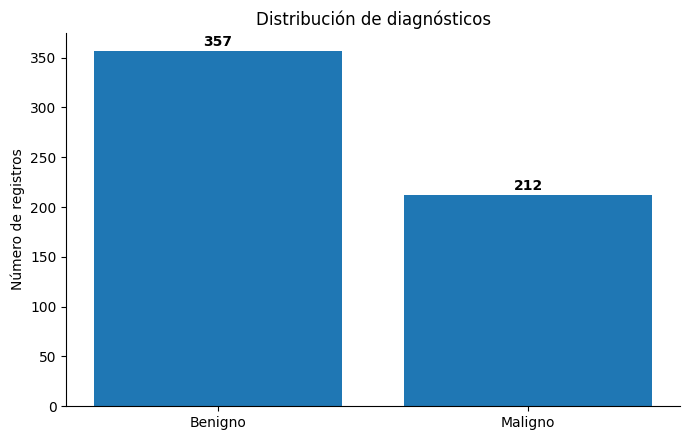

In [4]:

# Distribución de clases
conteos = df['riesgo_maligno'].value_counts().sort_index()
labels = ['Benigno', 'Maligno']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, conteos.values)
ax.set_title('Distribución de diagnósticos')
ax.set_ylabel('Número de registros')
for bar, value in zip(bars, conteos.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 5, str(value), ha='center', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


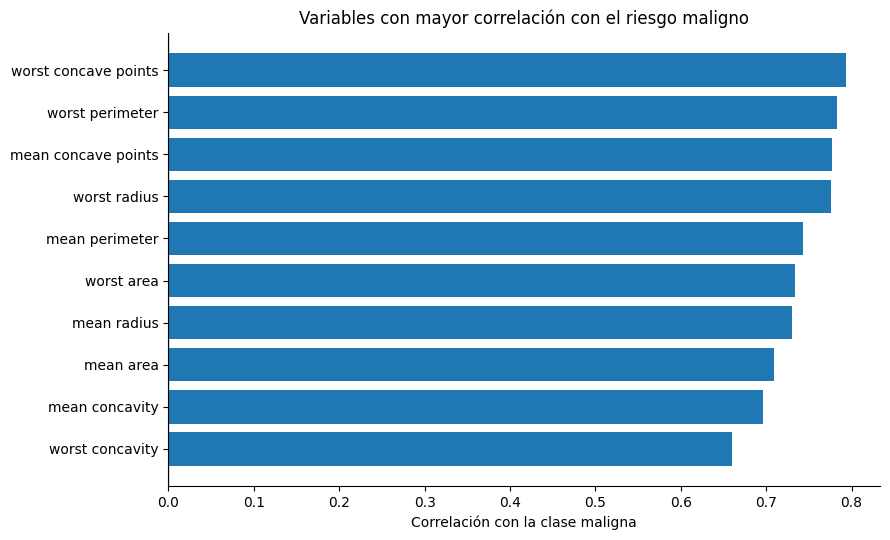

,correlación
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360
worst concavity,0.659610


In [5]:

# Variables con mayor relación lineal con el riesgo maligno
correlaciones = (
    df.corr(numeric_only=True)['riesgo_maligno']
      .drop('riesgo_maligno')
      .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_correlaciones = correlaciones.head(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_correlaciones.index, top_correlaciones.values)
ax.set_title('Variables con mayor correlación con el riesgo maligno')
ax.set_xlabel('Correlación con la clase maligna')
ax.axvline(0, linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

top_correlaciones.sort_values(ascending=False).to_frame('correlación')


/tmp/ipykernel_759/3173355209.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([datos_benignos, datos_malignos], labels=['Benigno', 'Maligno'])
/tmp/ipykernel_759/3173355209.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([datos_benignos, datos_malignos], labels=['Benigno', 'Maligno'])


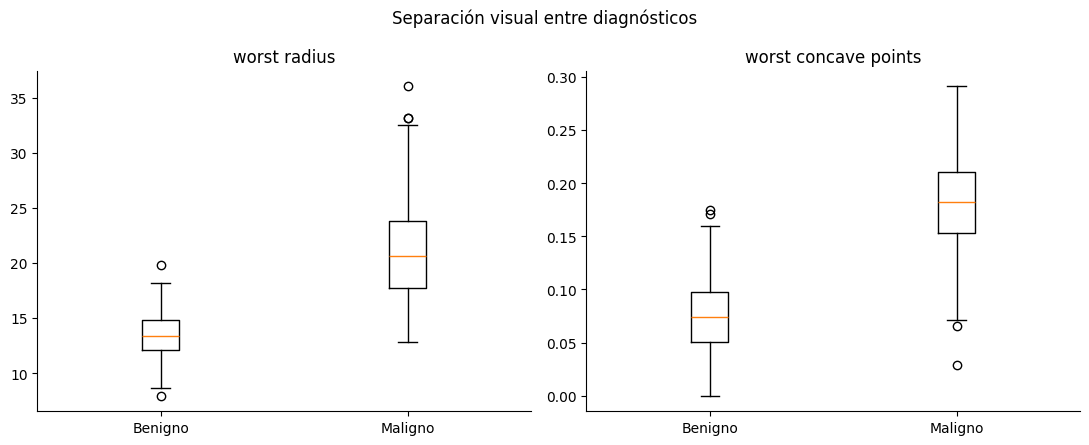

In [6]:

# Comparación de dos variables relevantes por clase
variables_clave = ['worst radius', 'worst concave points']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, columna in zip(axes, variables_clave):
    datos_benignos = df.loc[df['riesgo_maligno'] == 0, columna]
    datos_malignos = df.loc[df['riesgo_maligno'] == 1, columna]
    ax.boxplot([datos_benignos, datos_malignos], labels=['Benigno', 'Maligno'])
    ax.set_title(columna)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Separación visual entre diagnósticos')
plt.tight_layout()
plt.show()



### Hallazgos del EDA

1. El conjunto tiene más registros benignos que malignos, pero ambas clases cuentan con suficientes observaciones para entrenar y evaluar el modelo.
2. Variables relacionadas con el tamaño, perímetro, área y puntos cóncavos muestran una fuerte relación con la clase maligna.
3. Las distribuciones se superponen parcialmente; por ello se justifica un clasificador no lineal como SVM con kernel RBF.


## 5. Separación de variables y división train/test

In [7]:

X = df.drop(columns=['riesgo_maligno'])
y = df['riesgo_maligno']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)
print()
print('Proporción maligna en entrenamiento:', round(y_train.mean(), 3))
print('Proporción maligna en prueba:', round(y_test.mean(), 3))


Entrenamiento: (455, 30)
Prueba: (114, 30)

Proporción maligna en entrenamiento: 0.374
Proporción maligna en prueba: 0.368



## 6. Pipeline de preprocesamiento y modelo SVM

Se utiliza un `Pipeline` para asegurar que el escalado y la predicción siempre se ejecuten en el mismo orden:

1. `StandardScaler`: aprende media y desviación estándar únicamente con los datos de entrenamiento.
2. `SVC` con kernel RBF: modela fronteras no lineales.
3. `class_weight='balanced'`: asigna mayor atención a la clase menos frecuente.
4. `probability=True`: permite estimar una probabilidad de riesgo para apoyar decisiones.


In [8]:

pipeline_svm = Pipeline(steps=[
    ('escalador', StandardScaler()),
    ('modelo', SVC(
        kernel='rbf',
        C=2.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

pipeline_svm.fit(X_train, y_train)
print('Modelo SVM entrenado correctamente.')


Modelo SVM entrenado correctamente.


## 7. Evaluación del modelo

In [9]:

predicciones = pipeline_svm.predict(X_test)
probabilidades_maligno = pipeline_svm.predict_proba(X_test)[:, 1]

metricas = pd.Series({
    'Accuracy': accuracy_score(y_test, predicciones),
    'Precision_maligno': precision_score(y_test, predicciones),
    'Recall_maligno': recall_score(y_test, predicciones),
    'F1_maligno': f1_score(y_test, predicciones),
    'ROC_AUC': roc_auc_score(y_test, probabilidades_maligno)
})

print(metricas.round(4))
print()
print('Reporte de clasificación:')
print(classification_report(y_test, predicciones, target_names=['Benigno', 'Maligno']))


Accuracy             0.9825
Precision_maligno    1.0000
Recall_maligno       0.9524
F1_maligno           0.9756
ROC_AUC              0.9950
dtype: float64

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.97      1.00      0.99        72
     Maligno       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



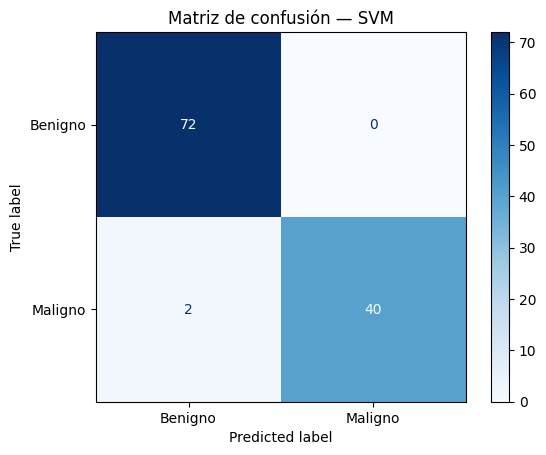

In [10]:

# Matriz de confusión
cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión — SVM')
plt.grid(False)
plt.show()


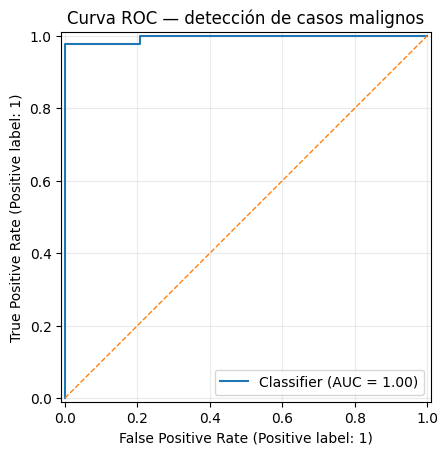

In [11]:

# Curva ROC
RocCurveDisplay.from_predictions(y_test, probabilidades_maligno)
plt.title('Curva ROC — detección de casos malignos')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.grid(alpha=0.25)
plt.show()



### Interpretación ejecutiva de las métricas

- **Accuracy:** porcentaje total de diagnósticos clasificados correctamente.
- **Recall maligno:** porcentaje de casos malignos reales detectados. Es una métrica crítica porque un falso negativo puede retrasar una revisión especializada.
- **Precision maligno:** de todos los registros señalados como malignos, cuántos realmente lo eran.
- **F1:** equilibrio entre precision y recall para la clase maligna.
- **ROC AUC:** capacidad global del modelo para separar ambas clases a distintos umbrales.


## 8. Importancia de variables mediante permutación

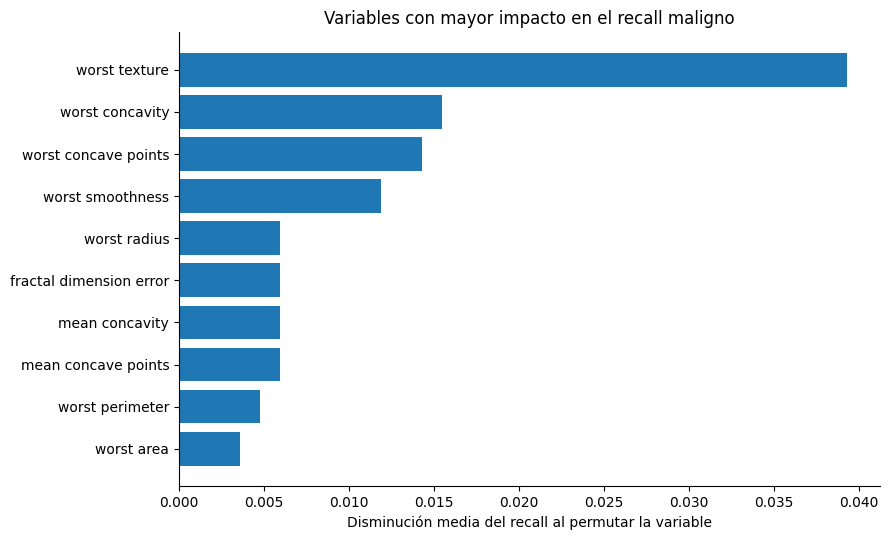

,importancia_permutación
worst texture,0.039286
worst concavity,0.015476
worst concave points,0.014286
worst smoothness,0.011905
fractal dimension error,0.005952
worst radius,0.005952
mean concave points,0.005952
mean concavity,0.005952
worst perimeter,0.004762
worst area,0.003571


In [12]:

# La importancia por permutación mide cuánto disminuye el desempeño al alterar cada variable.
resultado_perm = permutation_importance(
    pipeline_svm,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring='recall'
)

importancias = pd.Series(
    resultado_perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

top_importancias = importancias.head(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_importancias.index, top_importancias.values)
ax.set_title('Variables con mayor impacto en el recall maligno')
ax.set_xlabel('Disminución media del recall al permutar la variable')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

top_importancias.sort_values(ascending=False).to_frame('importancia_permutación')


## 9. Predicción con datos nuevos

In [13]:

# Se construyen dos perfiles representativos usando medianas del conjunto de entrenamiento.
# De esta manera se conserva una combinación de variables clínicamente coherente.
perfil_alto_riesgo = X_train.loc[y_train == 1].median()
perfil_bajo_riesgo = X_train.loc[y_train == 0].median()

nuevos_casos = pd.DataFrame(
    [perfil_alto_riesgo, perfil_bajo_riesgo],
    index=['Perfil clínico de alto riesgo', 'Perfil clínico de bajo riesgo']
)

pred_nuevas = pipeline_svm.predict(nuevos_casos)
prob_nuevas = pipeline_svm.predict_proba(nuevos_casos)[:, 1]

resultados_nuevos = pd.DataFrame({
    'clasificación': np.where(pred_nuevas == 1, 'Maligno', 'Benigno'),
    'probabilidad_maligno': prob_nuevas
}, index=nuevos_casos.index)

resultados_nuevos.style.format({'probabilidad_maligno': '{:.2%}'})


,clasificación,probabilidad_maligno
Perfil clínico de alto riesgo,Maligno,100.00%
Perfil clínico de bajo riesgo,Benigno,0.02%



### Uso propuesto de la predicción

El resultado puede funcionar como un **mecanismo de priorización**:

- Registros con alta probabilidad de malignidad: revisión especializada prioritaria.
- Registros con baja probabilidad: continúan el flujo clínico normal.
- Casos cercanos al umbral: revisión humana adicional antes de tomar decisiones.

La predicción siempre utiliza el mismo pipeline de escalado y SVM entrenado, garantizando trazabilidad y evitando diferencias entre entrenamiento y uso.



## 10. Conclusiones

1. Se construyó un pipeline completo y reproducible desde la carga de datos hasta la predicción de casos nuevos.
2. El algoritmo seleccionado fue **SVM con kernel RBF**, tomado de los algoritmos trabajados en los laboratorios y diferente de Random Forest.
3. El modelo obtuvo un desempeño alto en el conjunto de prueba, con especial atención al **recall de la clase maligna**, métrica relevante para disminuir falsos negativos.
4. La matriz de confusión y la curva ROC muestran que el modelo separa adecuadamente registros benignos y malignos, aunque todavía puede cometer errores.
5. Las variables asociadas con tamaño, perímetro y concavidad aportan información importante al proceso predictivo.
6. La recomendación es utilizar el modelo como apoyo para priorizar revisiones, no como sustituto del diagnóstico médico.

### Limitaciones y siguientes pasos

- El conjunto de datos es académico y no representa toda la diversidad de pacientes, equipos o instituciones.
- Antes de un uso real se requiere validación externa, revisión ética, protección de datos y evaluación por especialistas.
- Se recomienda ajustar el umbral de decisión según el costo de falsos negativos y falsos positivos.
- Debe monitorearse el desempeño del modelo con datos nuevos para detectar cambios en la población.
